In [5]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

import sys

sys.path.insert(0, "../utils")

from modules import create_grid
from plots import *
from string_handling import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [6]:
shapefile_path = "../../../Shapefiles/Cameroon Shapefiles/new/"
case_path = "../data/"

In [7]:
cameroon_nord_shp = gpd.read_file(f"{shapefile_path}Nord_region_Level3.shp",  encoding=enc)
cameroon_ext_nord_shp = gpd.read_file(f"{shapefile_path}ExtremeNord_region_Level3.shp",  encoding=enc)

cameroon_shp = gpd.GeoDataFrame(pd.concat([cameroon_nord_shp, cameroon_ext_nord_shp], ignore_index=True))

In [8]:
cameroon_cases = pd.read_csv(f"{case_path}CM_MAL_cases_GID2_2015-2024_processed.csv", encoding=enc)

In [9]:
cameroon_shp.head()

,OBJECTID,Nom_AS,Code_AS,District_S,Code_DS,Nom_Arrond,Code_Arron,Nom_Dept,Code_Dept,Nom_Region,Code_Reg,Id_Arrond,Pays,Code_RS,Id_DS,AVS,Autre_nom,Eff_AVS,Noms_AVS,A_statuer,No_decret,Date_creat,TITRE,Superficie,geometry
0,861,Gor,04TCH04,Tchollire,TCH,Madingring,04 04 04,Mayo-Rey,04 04,Nord,04,A185,Cameroun,NOR,182,None,None,0,None,None,None,None,GOR,6.364798e+08,"POLYGON ((14.82946 8.80523, 14.82959 8.80542, ..."
1,862,Kali,04TCH02,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,KALI,1.520400e+09,"POLYGON ((14.25497 8.47303, 14.25528 8.47297, ..."
2,863,Tchollire,04TCH01,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,TCHOLLIRE,2.045532e+09,"POLYGON ((14.10170 8.52491, 14.10191 8.52468, ..."
3,864,Gamba,04TCH09,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,GAMBA,1.525708e+09,"POLYGON ((13.73985 8.05249, 13.74000 8.05274, ..."
4,865,Sakdjé,04TCH08,Tchollire,TCH,Tchollire,04 04 01,Mayo-Rey,04 04,Nord,04,A328,Cameroun,NOR,182,None,None,0,None,None,None,None,SAKDJÉ,6.539222e+08,"POLYGON ((13.61775 8.35648, 13.61863 8.35606, ..."


In [10]:
cameroon_cases.head()

,GID0,GID2,GID3,Facility,Year,Month,dt_placement,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,extreme-nord,bogo,balaza,csi balaza alcali,2015,1,01-2015,49.0,43.0,2.0,94.0,3.0,12.0,2.0,17.0,3.0,12.0,2.0,17.0,0.0,0.0,0.0,0.0
1,extreme-nord,bogo,balda,csi balda,2015,1,01-2015,2.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,extreme-nord,bogo,bogo,csi bogo,2015,1,01-2015,19.0,53.0,0.0,72.0,17.0,51.0,0.0,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,extreme-nord,bogo,bogo,hd bogo,2015,1,01-2015,6.0,10.0,3.0,19.0,5.0,7.0,3.0,15.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,extreme-nord,bogo,borai,csi borai,2015,1,01-2015,16.0,14.0,1.0,31.0,4.0,3.0,1.0,8.0,4.0,3.0,1.0,8.0,0.0,0.0,0.0,0.0


In [11]:
cameroon_shp = cameroon_shp.to_crs(epsg=4326)
cameroon_shp.drop(columns=['OBJECTID','Code_AS','Code_DS','Nom_Arrond','Code_Arron','Code_Dept','Code_Reg','Id_Arrond',
                           'Pays','Code_RS','Id_DS','AVS','Autre_nom', 'Eff_AVS', 'Noms_AVS', 'A_statuer', 'No_decret',
                            'Date_creat', 'TITRE', 'Superficie'], inplace = True)
cameroon_shp.rename(columns={"Nom_AS": "GID3", "District_S": "GID2", "Nom_Dept": "GID1", "Nom_Region" : "GID0"}, inplace = True)
cameroon_shp['GID0'] = cameroon_shp['GID0'].str.lower()
cameroon_shp['GID0'] = cameroon_shp['GID0'].apply(lambda x : remove_accents(x))
cameroon_shp['GID1'] = cameroon_shp['GID1'].str.lower()
cameroon_shp['GID1'] = cameroon_shp['GID1'].apply(lambda x : remove_accents(x))
cameroon_shp['GID2'] = cameroon_shp['GID2'].str.lower()
cameroon_shp['GID2'] = cameroon_shp['GID2'].apply(lambda x : remove_accents(x))
cameroon_shp['GID3'] = cameroon_shp['GID3'].str.lower()
cameroon_shp['GID3'] = cameroon_shp['GID3'].apply(lambda x : remove_accents(x))

cameroon_cases['GID0'] = cameroon_cases['GID0'].str.replace("-", " ", regex=False)

In [12]:
case_columns = ['Case_UND5', 'Case_OVR5', 'Case_PRGN', 'Case_TOTAL',
                'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL', 
                'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL' 
                ]

cameroon_cases[case_columns] = cameroon_cases[case_columns].astype('Int64') 

In [13]:
cameroon_shp.head()

,GID3,GID2,GID1,GID0,geometry
0,gor,tchollire,mayo-rey,nord,"POLYGON ((14.82946 8.80523, 14.82959 8.80542, ..."
1,kali,tchollire,mayo-rey,nord,"POLYGON ((14.25497 8.47303, 14.25528 8.47297, ..."
2,tchollire,tchollire,mayo-rey,nord,"POLYGON ((14.10170 8.52491, 14.10191 8.52468, ..."
3,gamba,tchollire,mayo-rey,nord,"POLYGON ((13.73985 8.05249, 13.74000 8.05274, ..."
4,sakdje,tchollire,mayo-rey,nord,"POLYGON ((13.61775 8.35648, 13.61863 8.35606, ..."


In [14]:
cameroon_cases.head()

,GID0,GID2,GID3,Facility,Year,Month,dt_placement,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,extreme nord,bogo,balaza,csi balaza alcali,2015,1,01-2015,49,43,2,94,3,12,2,17,3,12,2,17,0,0,0,0
1,extreme nord,bogo,balda,csi balda,2015,1,01-2015,2,5,0,7,0,0,0,0,0,0,0,0,0,0,0,0
2,extreme nord,bogo,bogo,csi bogo,2015,1,01-2015,19,53,0,72,17,51,0,68,0,0,0,0,0,0,0,0
3,extreme nord,bogo,bogo,hd bogo,2015,1,01-2015,6,10,3,19,5,7,3,15,1,0,0,1,0,0,0,0
4,extreme nord,bogo,borai,csi borai,2015,1,01-2015,16,14,1,31,4,3,1,8,4,3,1,8,0,0,0,0


<Axes: >

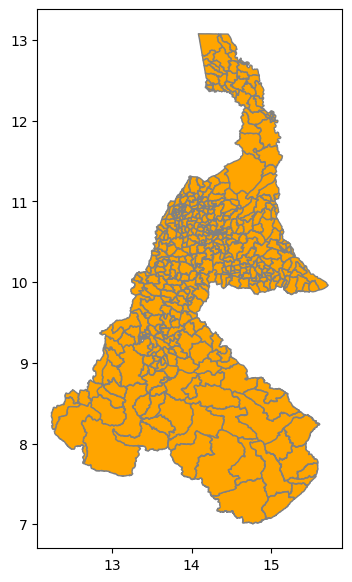

In [15]:
cameroon_shp.plot(facecolor="none", edgecolor='grey', figsize=(5,7), color='orange')

In [16]:
missing_gid0 = cameroon_cases[~cameroon_cases['GID0'].isin(cameroon_shp['GID0'])]
missing_gid2 = cameroon_cases[~cameroon_cases['GID2'].isin(cameroon_shp['GID2'])]
missing_gid3 = cameroon_cases[~cameroon_cases['GID3'].isin(cameroon_shp['GID3'])]

In [17]:
missing_gid0.GID0.sort_values().unique()

array([], dtype=object)

In [18]:
missing_gid2.GID2.sort_values().unique()

array(['makary', 'waza'], dtype=object)

In [19]:
missing_gid3.GID3.sort_values().unique()

array(['amchedire', 'bangana', 'barndake', 'bimba (poli)', 'bosgoye',
       'boumedje', 'dagai (gazawa)', 'dargala 1', 'djalingo (hina)',
       'djalingo (ngong)', 'djarengol kodek', 'djounde', 'dogba 1',
       'dolla', 'domayo kaigama 1', 'domo', 'doualare 1',
       'dougour-tchere (pnlp)', 'doumrou (kaele)', 'douroum (meri)',
       'gazawa 1', 'gazawa 2', 'gobo 1', 'gobo 2', 'golibai (pnlp)',
       'golondakri', 'goulfey gana', 'gouloua momboï', "gouzda-m'lay",
       'guinane', 'guiriou grand', 'hinale', 'houlouf', 'houloum (pnlp)',
       'kaheo', 'karam', 'keleo (pnlp)', 'kilwo', 'kodogo', 'kongola',
       'kouro mokdaye', 'lahai (pnlp)', 'lam (bibemi)', 'lam (figuil)',
       'ldamtsai goda', 'lopere 1', "m'tskar", 'maboudji (pnlp)',
       'mada kolkoch', 'makabaye 1', 'makary', 'mandaigoum', 'mandaka',
       'mangave dalil', 'massa koutweita', 'mbai mboum',
       'mbaka (touboro)', 'mbang rey', 'mbola (bourha)', 'miogoye',
       'mogom (kar hay)', 'mogom (mindif)', 'm

In [20]:
cameroon_cases['GID2'] = cameroon_cases['GID2'].replace({'makary': 'makari'})
cameroon_cases['GID2'] = cameroon_cases['GID2'].replace({'waza': 'mora'})

cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'amchedire': 'amchidire'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'bangana': 'bagana'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'barndake': 'barndake 2'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'bimba (poli)': 'bimba'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'bosgoye': 'djongdong'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'boumedje': 'boumedjere'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'dagai (gazawa)': 'dagai'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'dargala 1': 'dargala'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'djalingo (hina)': 'hina'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'djalingo (ngong)': 'djalingo'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'djarengol kodek': 'kodek'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'djounde': 'djaounde'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'dogba 1': 'dogba'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'dolla': 'dola'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'domayo kaigama 1': 'domayo kamanjo kaigama'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'domo': 'dana'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'doualare 1': 'doualare'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'dougour-tchere (pnlp)': 'meri'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'doumrou (kaele)': 'doumrou'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'douroum (meri)': 'douroum'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'gazawa 1': 'gazawa'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'gazawa 2': 'gazawa'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'gobo 1': 'gobo'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'gobo 2': 'gobo'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'golibai (pnlp)': 'golibai'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'golondakri': 'touloum'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'goulfey gana': 'gana'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'gouloua momboï': 'gouloua momboi'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({"gouzda-m'lay": 'gouzda wayam'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'guinane': 'kalfou'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'guiriou grand': 'gobo'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'hinale': 'kalakafra'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'houlouf': 'houla'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'houloum (pnlp)': 'houloum'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'kaheo': 'kaewo'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'karam': 'madiako'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'keleo (pnlp)': 'keleo'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'kilwo': 'douvangar'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'kodogo': 'dargala'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'kongola': 'moutourwa'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'kouro mokdaye': 'kouromokdaye'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'lahai (pnlp)': 'lahai'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'lam (bibemi)': 'lam'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'lam (figuil)': 'figuil'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'ldamtsai goda': 'goda ldamtsai'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'lopere 1': 'lopere'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({"m'tskar": 'mstikar'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'maboudji (pnlp)': 'maboudji'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mada kolkoch': 'mada-kolkoch'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'makabaye 1': 'makabaye'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'makary': 'makari'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mandaigoum': 'doubane'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mandaka': 'mandaka chechem'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mangave dalil': 'mangave - dalil'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'massa koutweita': 'nouldaina'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mbai mboum': 'mbai-mboum'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mbaka (touboro)': 'mbaka'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mbang rey': 'mbang-rey'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mbola (bourha)': 'mbola bourha'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'miogoye': 'vounaloum'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mogom (kar hay)': 'mogom'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mogom (mindif)': 'mindif'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mokolo 1 (mokolo)': 'mokolo 1'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mokong centre': 'mokong'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'mounhour': 'mouhour'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'naari': "na'ari"})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'ndjimini': 'amdjagara'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'ngay lara': 'ngai-lara'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'ngoulmong (pnlp)': 'ngoulmoung'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'nguetchewe': 'nghetchewe'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'nguéring': 'guibi'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'oudjilla': 'oudjila'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'oulargo': 'mogom'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'oupaï-manak': 'mozogo'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'ouro chetima': 'ouro tchede'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'palia (pnlp)': 'palia'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'seradoumda': 'ndoukoula'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'souari': 'be'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'takreo-yoldeo': 'takreo - yoldeo'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'tapare (poli)': 'tapare'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'tchamba (poli)': 'tchamba'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'tchouvouk (pnlp)': 'tchouvouk'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'tongo (lagdo)': 'tongo'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'torock': 'guidiguis'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'yagoua 1': 'yagoua'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'yagoua 2': 'vada toukou'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'yagoua 3': 'mass gaya'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'zagara': 'zileng'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'zalla (pnlp)': 'zalla'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'zogom (pnlp)': 'zogom'})
cameroon_cases['GID3'] = cameroon_cases['GID3'].replace({'zokok 1': 'zokok'})



In [21]:
missing_gid2 = cameroon_cases[~cameroon_cases['GID2'].isin(cameroon_shp['GID2'])]
missing_gid3 = cameroon_cases[~cameroon_cases['GID3'].isin(cameroon_shp['GID3'])]

In [22]:
missing_gid2.GID2.sort_values().unique()

array([], dtype=object)

In [23]:
missing_gid3.GID3.sort_values().unique()

array([], dtype=object)

In [24]:
cameroon_nord = cameroon_shp[cameroon_shp['GID0'] == 'nord'].copy()
cameroon_ext_nord = cameroon_shp[cameroon_shp['GID0'] == 'extreme nord'].copy()


In [25]:
cameroon_nord.reset_index(drop=True, inplace=True)
cameroon_ext_nord.reset_index(drop=True, inplace=True)

In [26]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid_nord = create_grid(empty_gdf, cameroon_nord, col_municipal='GID3', dimension=2)

e:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\../utils\modules.py:34: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()


<Axes: >

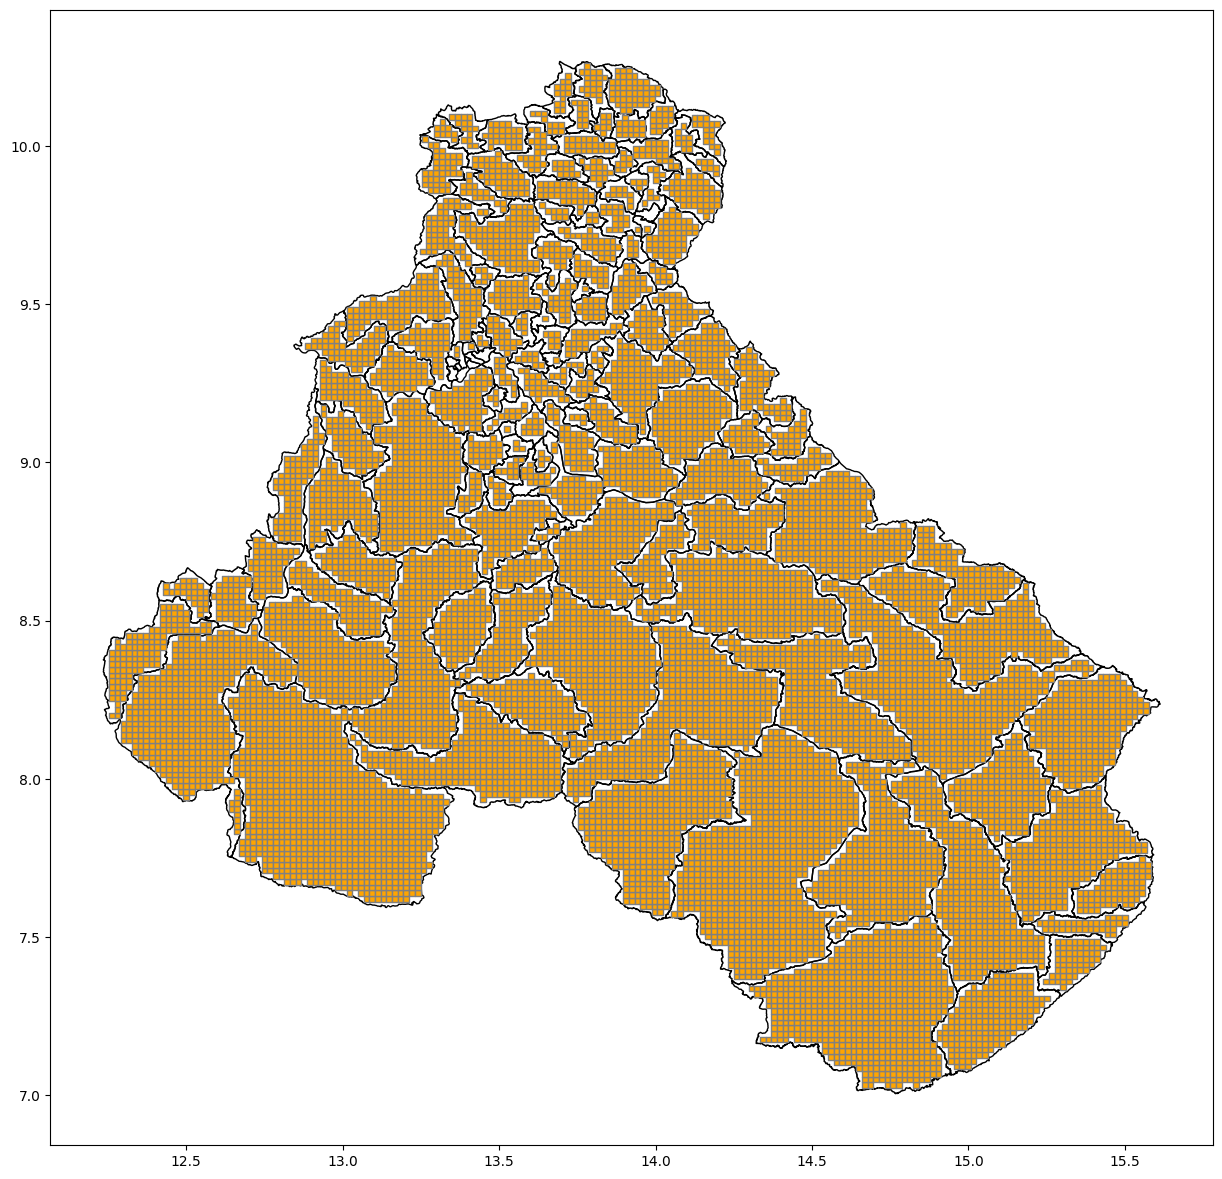

In [36]:
ax = cameroon_nord.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=1)
df_grid_nord.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [28]:
df_grid_nord.shape

(13004, 5)

In [34]:
df_grid_nord.GID3.unique().shape

(136,)

In [ ]:
set(cameroon_nord.GID3.unique())


(144,)